### 02.DataLoader

In [226]:
import sys
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
from pprint import pprint 

In [229]:
# Notebookの作業ディレクトリを基準にパスを追加
project_root = Path.cwd()
sys.path.append(str(project_root / "src"))

from myfunctions import detect_os, windows_to_wsl_path, check_config_paths

#check OS
print(f"isOS: {detect_os()}")

# RootDirectory
PROJECT_ROOT = windows_to_wsl_path(r"C:\Users\yohei\Desktop\physionet-ecg-image-digitization")
#PROJECT_ROOT = Path("/Users/yohe/Desktop/physionet-ecg-image-digitization")
print(f"isPath :{PROJECT_ROOT.exists()}")
# directorys data
list(PROJECT_ROOT.glob("*"))

ImportError: cannot import name 'check_config_paths' from 'myfunctions' (/home/yohehe/projects/ECG-Analysis/src/myfunctions.py)

In [230]:
class CONFIG:
    train_csv_path = PROJECT_ROOT / "train.csv"
    test_csv_path = PROJECT_ROOT / "test.csv"
    sample_submission_csv_path = PROJECT_ROOT / "sample_submission.parquet"
    train_data_dir = PROJECT_ROOT / "train"
    test_data_dir = PROJECT_ROOT / "test"

In [231]:
# CONFIGで設定したPathの確認
def check_config_paths(config_class):
    missing = []
    for attr in dir(config_class):
        if attr.startswith("_"):
            continue
        value = getattr(config_class, attr)
        if isinstance(value, Path):
            if not value.exists():
                missing.append((attr, value))
    if missing:
        print("以下のパスが存在しません:")
        for name, path in missing:
            print(f" - {name}: {path}")
    else:
        print("すべてのパスが存在します")

# 使用例
check_config_paths(CONFIG)


すべてのパスが存在します


DataFrame

In [232]:
import polars as pl
train_df = pl.read_csv(CONFIG.train_csv_path)
train_df = train_df.to_pandas()
#普通に動くね。なんで？

### 各データフォルダの構成

In [233]:
sample_id = str(train_df["id"][0])
sample_fs = str(train_df["fs"][0])
sample_sig_len = train_df[train_df['id'] == int(sample_id)]['sig_len'].values[0]

print(sample_id)
print(sample_fs)
print(sample_sig_len)

7663343
500
5000


In [234]:
#set sampleID
sample_id = str(train_df["id"][0])
print(sample_id)

#directory
sample_data_dir = CONFIG.train_data_dir / sample_id
print("sample Dir Exist:",sample_data_dir.exists())

# datalist
sample_data_path_list = list(sample_data_dir.glob("*"))
pprint(sample_data_path_list)

7663343
sample Dir Exist: True
[PosixPath('/mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/7663343/7663343-0001.png'),
 PosixPath('/mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/7663343/7663343-0003.png'),
 PosixPath('/mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/7663343/7663343-0004.png'),
 PosixPath('/mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/7663343/7663343-0005.png'),
 PosixPath('/mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/7663343/7663343-0006.png'),
 PosixPath('/mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/7663343/7663343-0009.png'),
 PosixPath('/mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/7663343/7663343-0010.png'),
 PosixPath('/mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/7663343/7663343-0011.png'),
 PosixPath('/mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/7663343/7663343-0012.png'),
 PosixPath('/mn

#csv

In [235]:
sample_data_csv = CONFIG.train_data_dir / sample_id / f"{sample_id}.csv"
print("sample Dir Exist:",sample_data_csv.exists())

sample Dir Exist: True


In [236]:
#sample_ecg_csv = pl.read_csv(sample_data_csv).to_pandas()
sample_ecg_csv = pd.read_csv(sample_data_csv)

sample_ecg_csv

,I,II,III,aVR,aVL,aVF,V1,V2,V3,V4,V5,V6
0,0.04,0.10,0.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.04,0.10,0.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.04,0.10,0.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.04,0.10,0.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.04,0.10,0.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,NaN,-0.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.065,-0.055,-0.025
4996,NaN,-0.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.065,-0.055,-0.025
4997,NaN,-0.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.065,-0.055,-0.025
4998,NaN,-0.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.065,-0.055,-0.025


In [237]:
### 
ecg_data = sample_ecg_csv

In [238]:
print(f"📋 Sample ECG ID: {sample_id}")
print(f"📊 Sampling Frequency: {sample_fs} Hz")
print(f"📏 Signal Length: {sample_sig_len} samples ({sample_sig_len/sample_fs:.1f} seconds)")
print(f"📌 ECG Data Shape: {ecg_data.shape}")
print(f"\n🔍 Available Leads: {list(ecg_data.columns)}")

display(ecg_data.head())

📋 Sample ECG ID: 7663343
📊 Sampling Frequency: 500 Hz


TypeError: ufunc 'divide' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

In [239]:
sample_sig_len = float(sample_sig_len)
sample_fs = float(sample_fs)

for lead in lead_names:
    ecg_data[lead] = pd.to_numeric(ecg_data[lead], errors="coerce")

time_axis = np.arange(len(ecg_data)) / sample_fs


/tmp/ipykernel_7729/632098507.py:42: UserWarning: Glyph 129728 (\N{ANATOMICAL HEART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/yohehe/yohenv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129728 (\N{ANATOMICAL HEART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


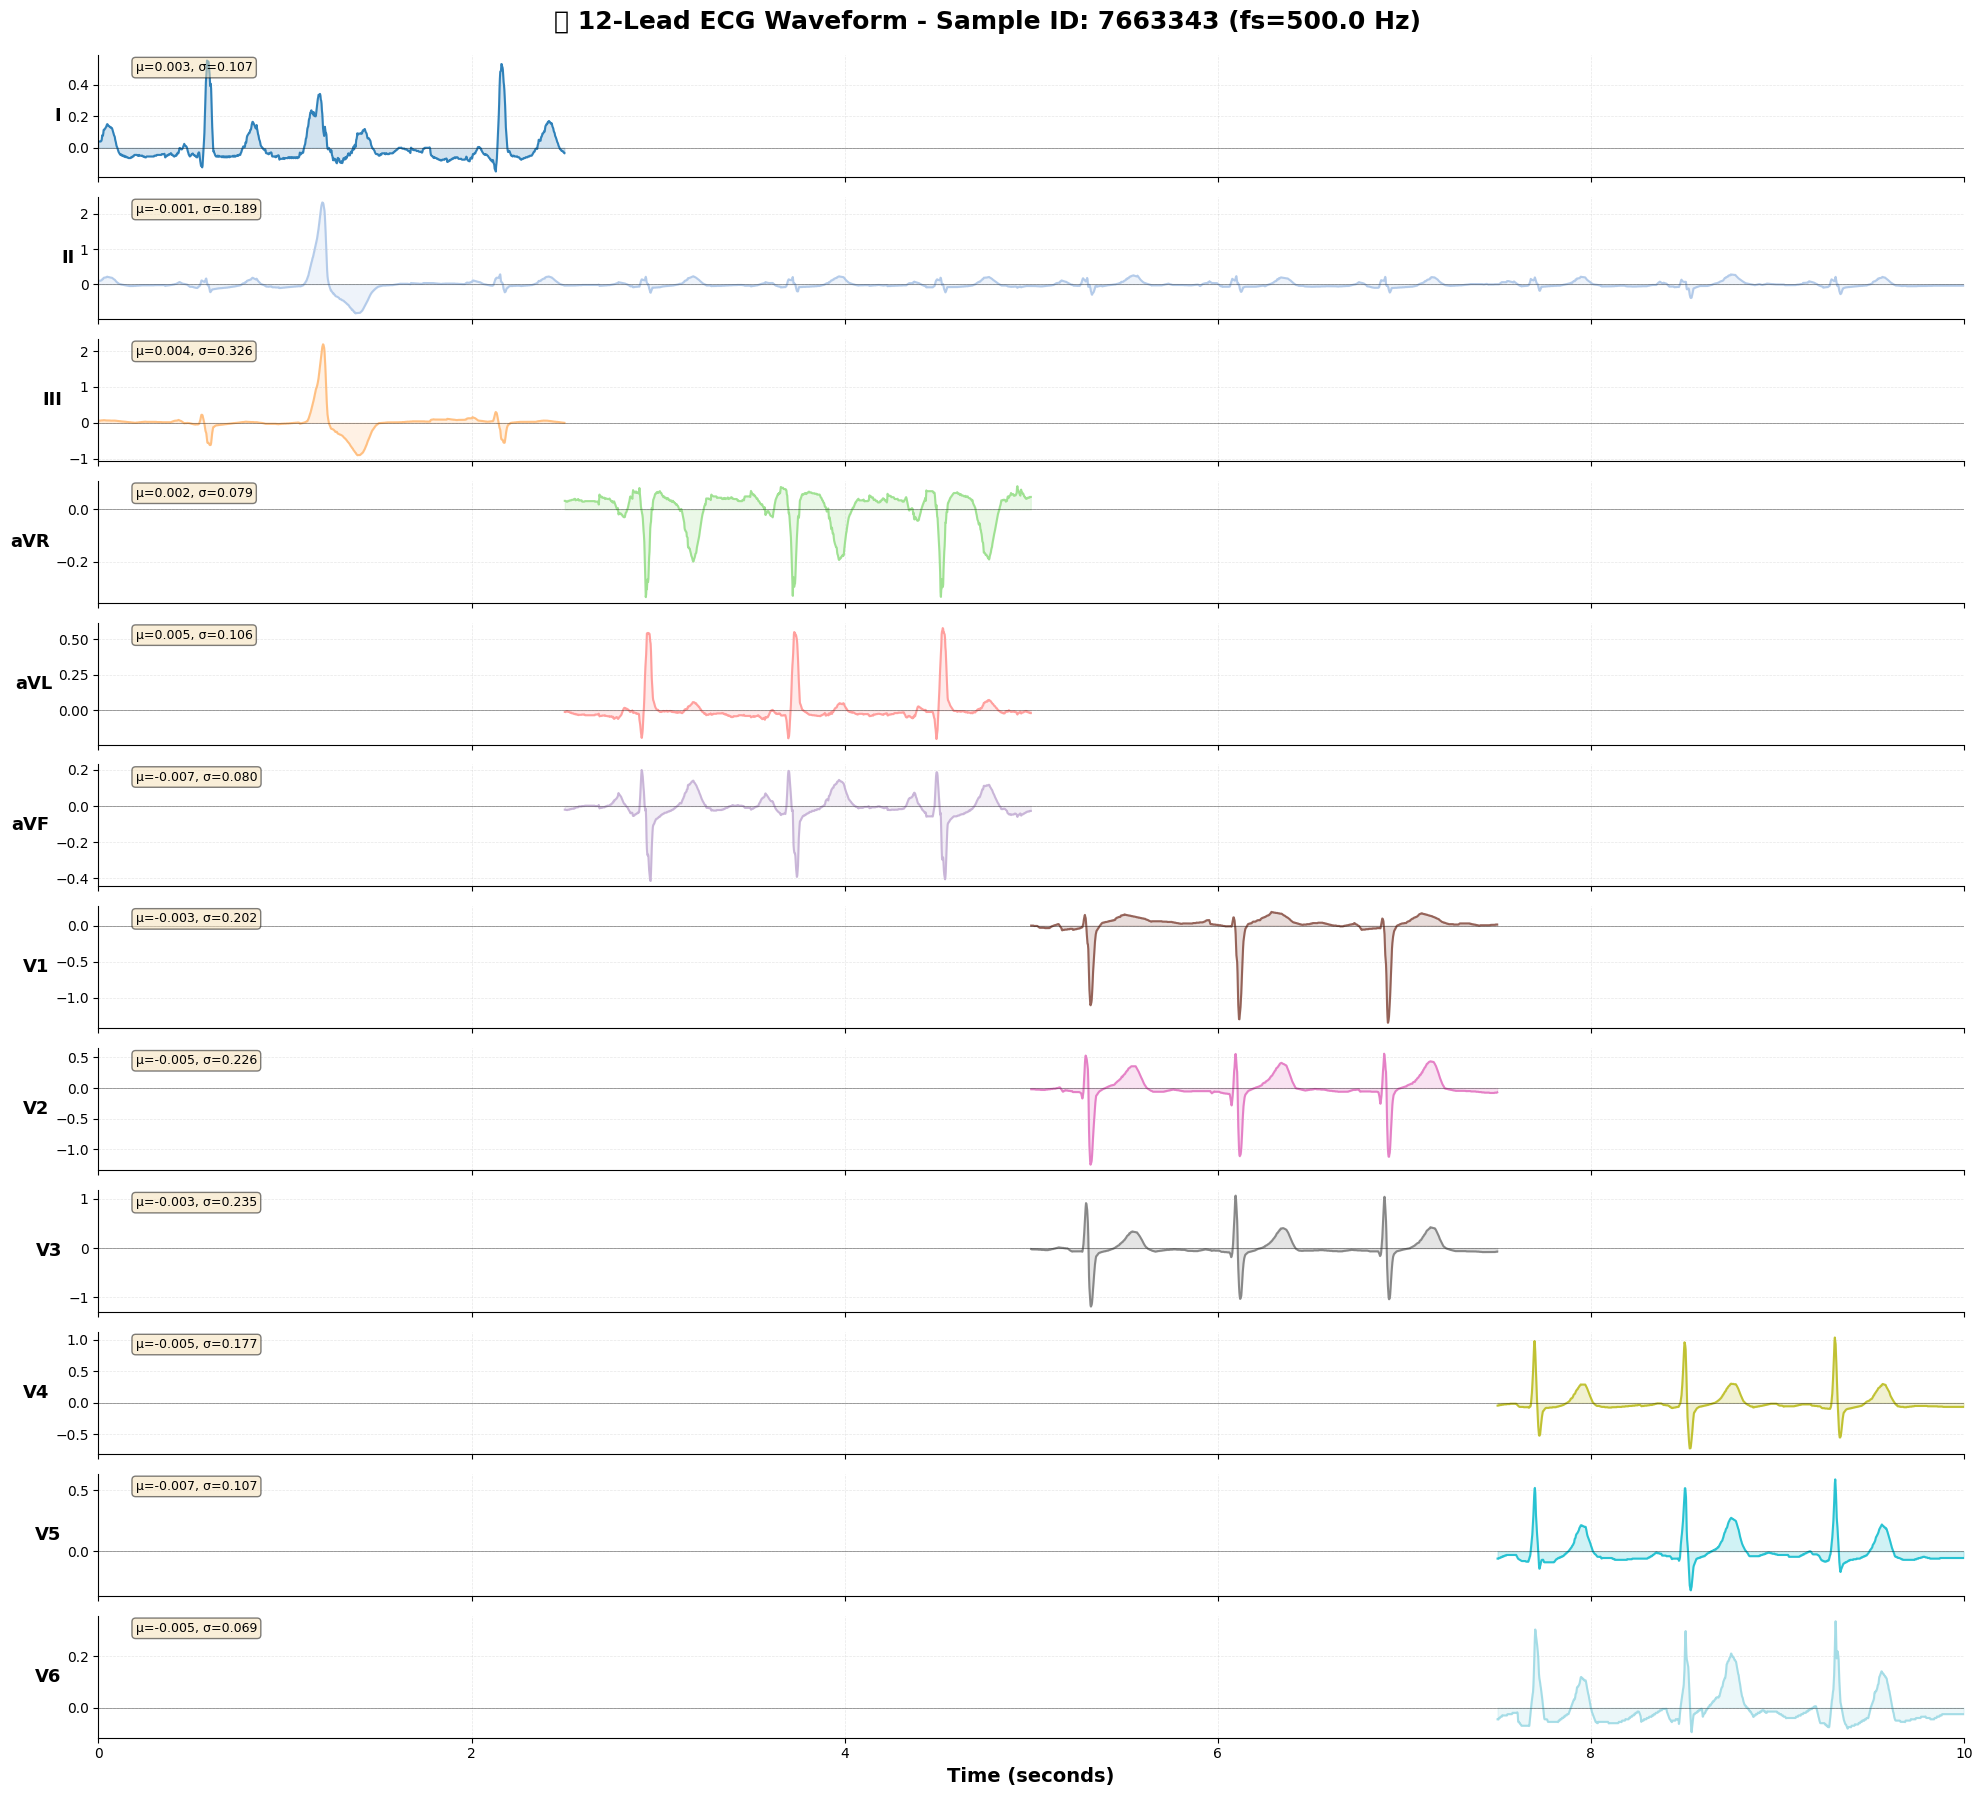

In [240]:
# Create beautiful 12-lead ECG visualization
lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
colors = plt.cm.tab20(np.linspace(0, 1, 12))

fig, axes = plt.subplots(12, 1, figsize=(20, 18), sharex=True)
fig.suptitle(f'🫀 12-Lead ECG Waveform - Sample ID: {sample_id} (fs={sample_fs} Hz)', 
             fontsize=18, fontweight='bold', y=0.995)

#time_axis = np.arange(len(ecg_data)) / sample_fs
for lead in lead_names:
    ecg_data[lead] = pd.to_numeric(ecg_data[lead], errors="coerce")

time_axis = np.arange(len(ecg_data)) / sample_fs


for idx, (ax, lead, color) in enumerate(zip(axes, lead_names, colors)):
    # Plot the waveform
    ax.plot(time_axis, ecg_data[lead], color=color, linewidth=1.5, alpha=0.9)
    ax.fill_between(time_axis, ecg_data[lead], alpha=0.2, color=color)
    
    # Styling
    ax.set_ylabel(lead, fontsize=13, fontweight='bold', rotation=0, ha='right', va='center')
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_xlim(0, len(ecg_data) / sample_fs)
    
    # Add horizontal line at zero
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
    
    # Remove spines for cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Calculate and display basic stats
    mean_val = ecg_data[lead].mean()
    std_val = ecg_data[lead].std()
    ax.text(0.02, 0.95, f'μ={mean_val:.3f}, σ={std_val:.3f}', 
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[-1].set_xlabel('Time (seconds)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [241]:
## sample image plot

In [242]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_ecg_12lead(sample_id, sample_fs, sample_sig_len, ecg_data):
    """
    12誘導ECG波形を描画する関数（カラーリングなし）

    Parameters:
    - sample_id (str or int): ECGサンプルID
    - sample_fs (float or int): サンプリング周波数（Hz）
    - sample_sig_len (int): 信号長（サンプル数）
    - ecg_data (pd.DataFrame): 12誘導ECGデータ（各列がリード）

    Returns:
    - None（matplotlibで表示）
    """
    # 型の安全性確保
    sample_fs = float(sample_fs)
    sample_sig_len = int(sample_sig_len)

    # リード名（順序付き）
    lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF',
                  'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

    # 各リードを数値型に変換
    for lead in lead_names:
        ecg_data[lead] = pd.to_numeric(ecg_data[lead], errors="coerce")

    # 時間軸（秒）
    time_axis = np.arange(len(ecg_data)) / sample_fs

    # プロット設定
    fig, axes = plt.subplots(12, 1, figsize=(20, 18), sharex=True)
    fig.suptitle(f'🫀 12-Lead ECG Waveform - Sample ID: {sample_id} (fs={sample_fs:.1f} Hz)',
                 fontsize=18, fontweight='bold', y=0.995)

    for idx, (ax, lead) in enumerate(zip(axes, lead_names)):
        ax.plot(time_axis, ecg_data[lead], color='black', linewidth=1.2, alpha=0.9)
        ax.fill_between(time_axis, ecg_data[lead], alpha=0.1, color='gray')

        ax.set_ylabel(lead, fontsize=13, fontweight='bold', rotation=0,
                      ha='right', va='center')
        ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
        ax.set_xlim(0, len(ecg_data) / sample_fs)
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        # 統計情報表示
        mean_val = ecg_data[lead].mean()
        std_val = ecg_data[lead].std()
        ax.text(0.02, 0.95, f'μ={mean_val:.3f}, σ={std_val:.3f}',
                transform=ax.transAxes, fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

    axes[-1].set_xlabel('Time (seconds)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [243]:
#set sampleID
sample_id = str(train_df["id"][1])
print(sample_id)

#directory
sample_data_dir = CONFIG.train_data_dir / sample_id
print("sample Dir Exist:",sample_data_dir.exists())

# datalist
sample_data_path_list = list(sample_data_dir.glob("*"))
pprint(sample_data_path_list)


10140238
sample Dir Exist: True
[PosixPath('/mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/10140238/10140238-0001.png'),
 PosixPath('/mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/10140238/10140238-0003.png'),
 PosixPath('/mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/10140238/10140238-0004.png'),
 PosixPath('/mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/10140238/10140238-0005.png'),
 PosixPath('/mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/10140238/10140238-0006.png'),
 PosixPath('/mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/10140238/10140238-0009.png'),
 PosixPath('/mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/10140238/10140238-0010.png'),
 PosixPath('/mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/10140238/10140238-0011.png'),
 PosixPath('/mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/10140238/10140238-0012.png

In [244]:
sample_id = str(train_df["id"][0])
sample_fs = str(train_df["fs"][0])
sample_sig_len = train_df[train_df['id'] == int(sample_id)]['sig_len'].values[0]

print(sample_id)
print(sample_fs)
print(sample_sig_len)

7663343
500
5000


In [245]:
### 
ecg_data = sample_ecg_csv

/tmp/ipykernel_7729/753893113.py:58: UserWarning: Glyph 129728 (\N{ANATOMICAL HEART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


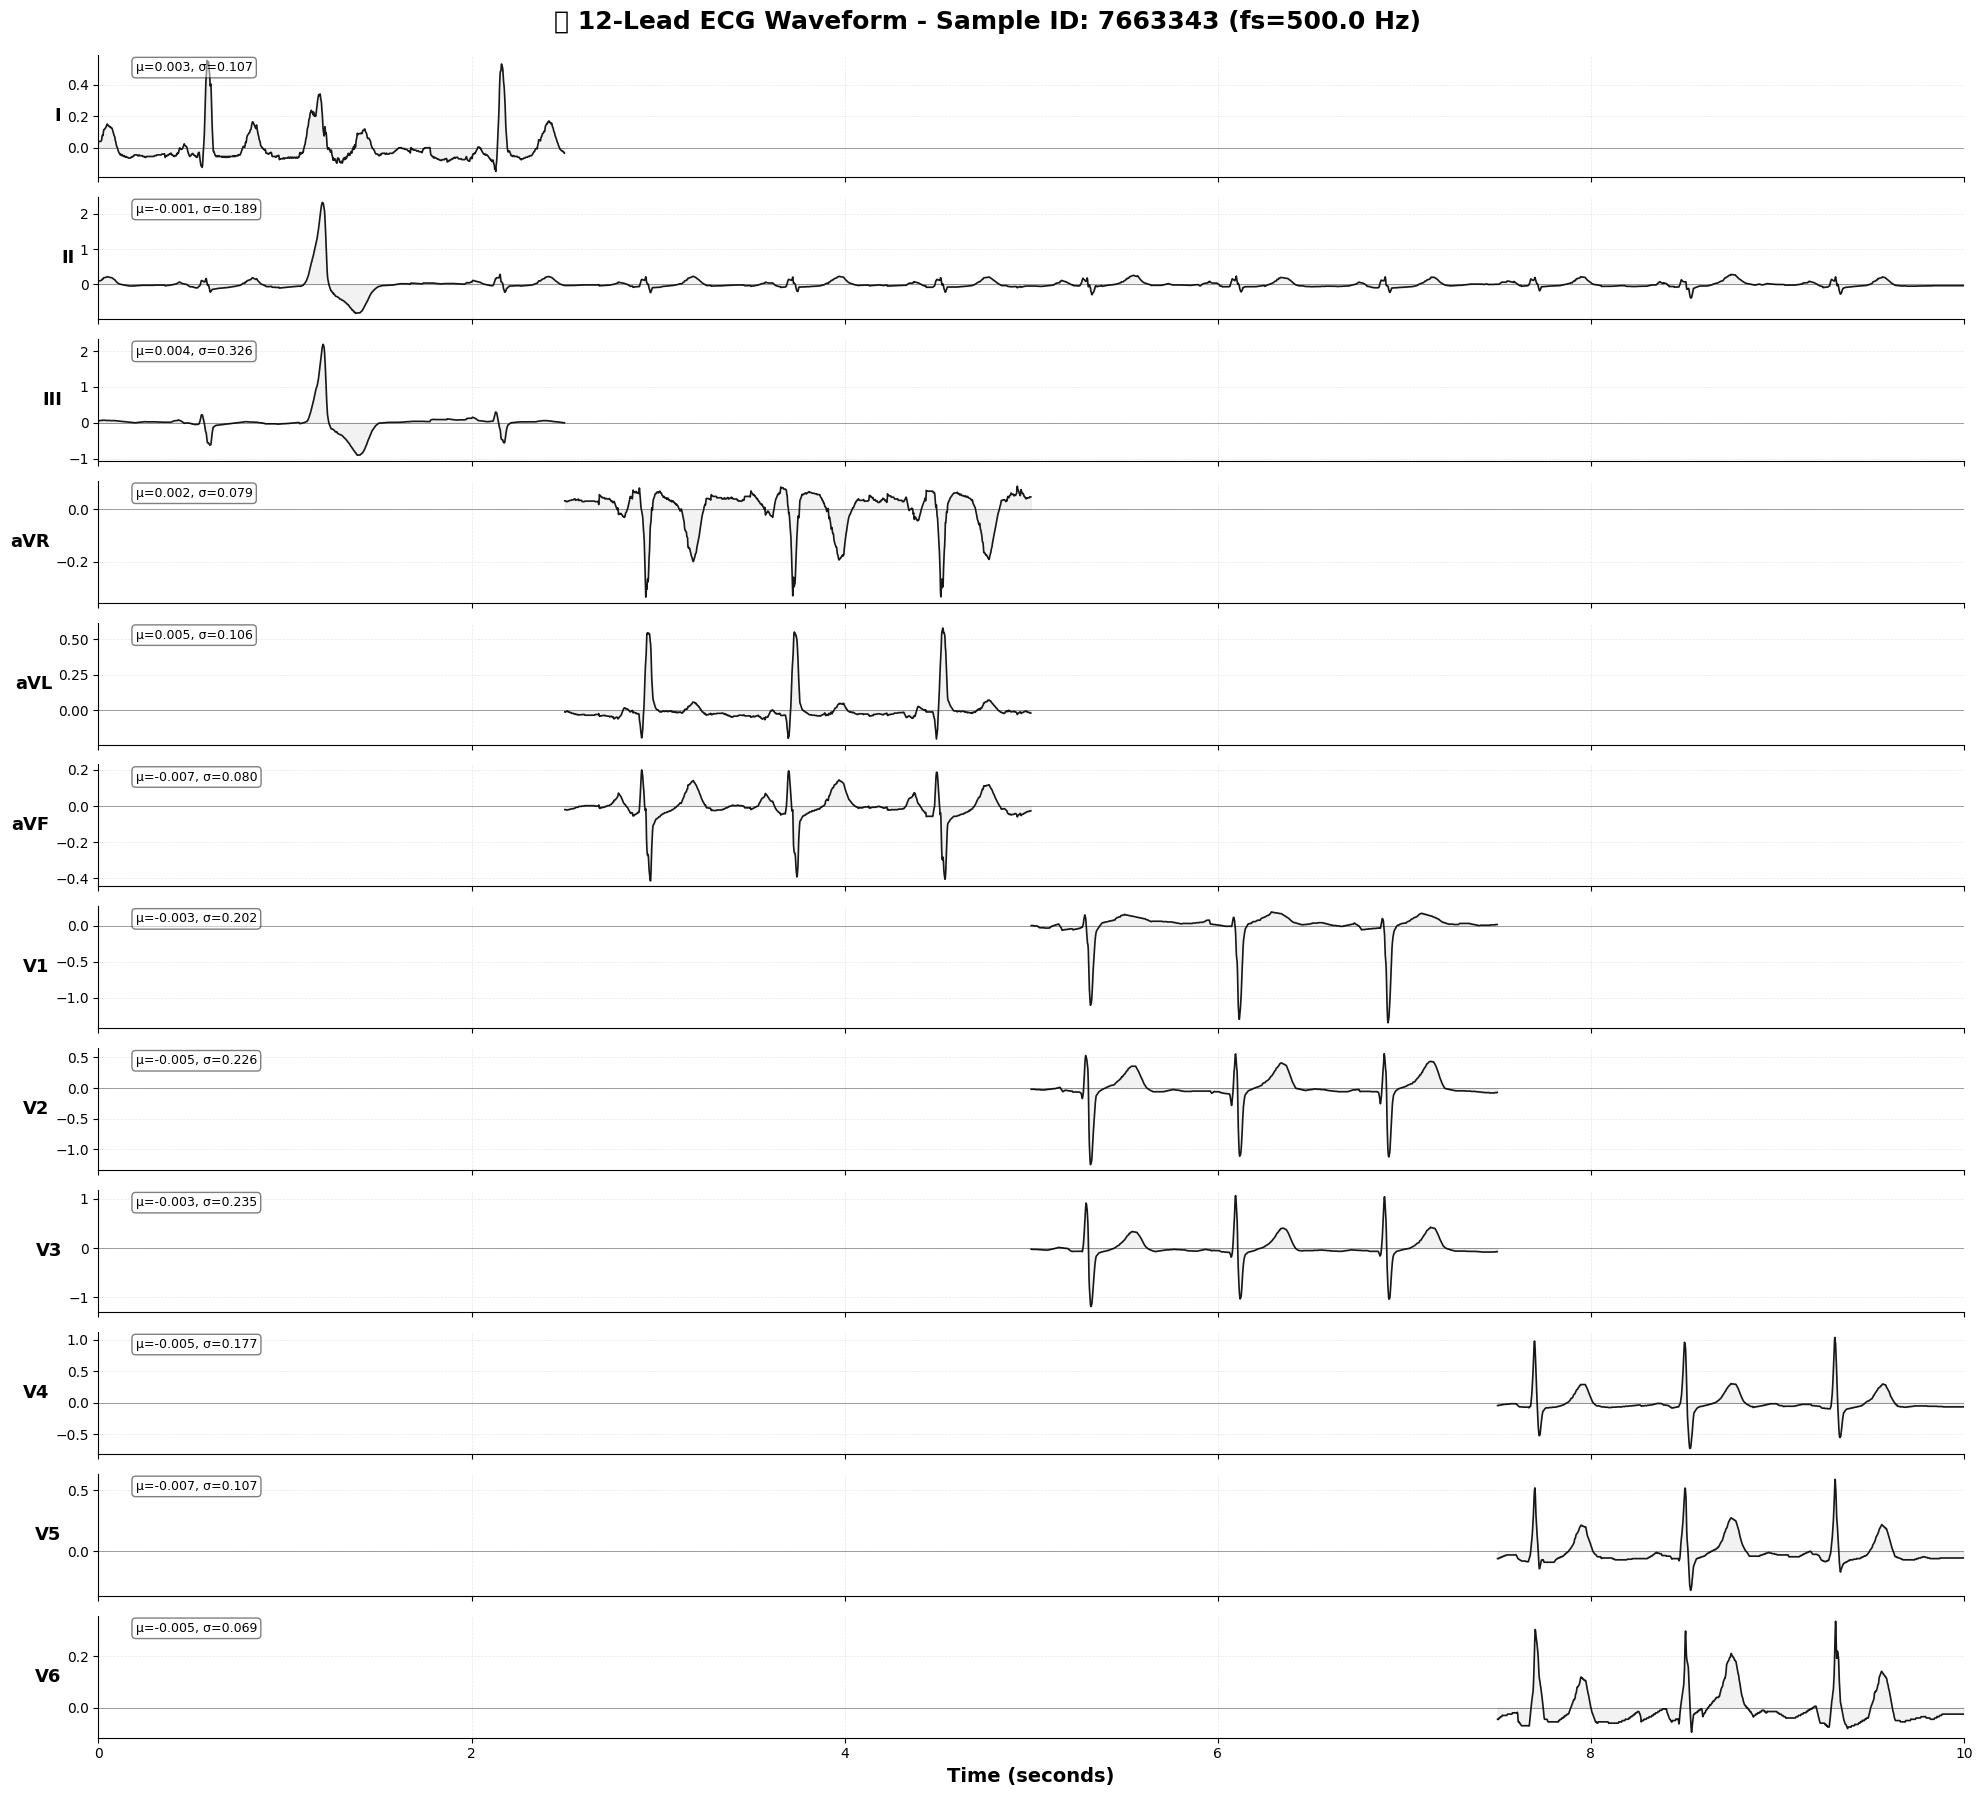

In [246]:
plot_ecg_12lead(sample_id=sample_id, sample_fs=sample_fs, sample_sig_len=sample_sig_len, ecg_data=ecg_data)

In [247]:
def extract_ecg_features_by_id(ecg_id: int, train_df: pd.DataFrame, config, is_plot: bool = True) -> dict:
    """
    ECG ID を指定して、特徴量抽出とオプションで12誘導波形描画を行う関数

    Parameters:
    - ecg_id (int): ECGサンプルID
    - train_df (pd.DataFrame): メタ情報（id, fs, sig_lenなど）
    - config (CONFIG): データディレクトリなどを含む設定クラス
    - is_plot (bool): Trueなら波形を描画、Falseなら描画しない

    Returns:
    - dict: 特徴量（各リードの平均・標準偏差など）を含む辞書
    """
    ecg_id = str(ecg_id)

    # メタ情報取得
    row = train_df[train_df["id"] == int(ecg_id)]
    if row.empty:
        raise ValueError(f"ID {ecg_id} が train_df に存在しません")

    sample_fs = float(row["fs"].values[0])
    sample_sig_len = int(row["sig_len"].values[0])

    # データ読み込み
    sample_data_dir = config.train_data_dir / ecg_id
    if not sample_data_dir.exists():
        raise FileNotFoundError(f"ディレクトリが存在しません: {sample_data_dir}")

    csv_files = list(sample_data_dir.glob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"CSVファイルが見つかりません: {sample_data_dir}")

    ecg_data = pd.read_csv(csv_files[0])

    # リード名
    lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF',
                  'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

    # 数値変換
    for lead in lead_names:
        ecg_data[lead] = pd.to_numeric(ecg_data[lead], errors="coerce")

    # 特徴量抽出
    features = {
        "id": ecg_id,
        "fs": sample_fs,
        "sig_len": sample_sig_len,
        "duration_sec": sample_sig_len / sample_fs,
        "lead_stats": {}
    }

    for lead in lead_names:
        lead_series = ecg_data[lead].dropna()
        features["lead_stats"][lead] = {
            "mean": lead_series.mean(),
            "std": lead_series.std(),
            "min": lead_series.min(),
            "max": lead_series.max(),
            "median": lead_series.median(),
        }

    # 描画（オプション）
    if is_plot:
        time_axis = np.arange(len(ecg_data)) / sample_fs
        fig, axes = plt.subplots(12, 1, figsize=(20, 18), sharex=True)
        fig.suptitle(f'🫀 12-Lead ECG Waveform - Sample ID: {ecg_id} (fs={sample_fs:.1f} Hz)',
                     fontsize=18, fontweight='bold', y=0.995)

        for idx, (ax, lead) in enumerate(zip(axes, lead_names)):
            ax.plot(time_axis, ecg_data[lead], color='black', linewidth=1.2, alpha=0.9)
            ax.fill_between(time_axis, ecg_data[lead], alpha=0.1, color='gray')

            ax.set_ylabel(lead, fontsize=13, fontweight='bold', rotation=0,
                          ha='right', va='center')
            ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
            ax.set_xlim(0, len(ecg_data) / sample_fs)
            ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

            mean_val = features["lead_stats"][lead]["mean"]
            std_val = features["lead_stats"][lead]["std"]
            ax.text(0.02, 0.95, f'μ={mean_val:.3f}, σ={std_val:.3f}',
                    transform=ax.transAxes, fontsize=9, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

        axes[-1].set_xlabel('Time (seconds)', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

    return features

/tmp/ipykernel_7729/336908516.py:88: UserWarning: Glyph 129728 (\N{ANATOMICAL HEART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/yohehe/yohenv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129728 (\N{ANATOMICAL HEART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


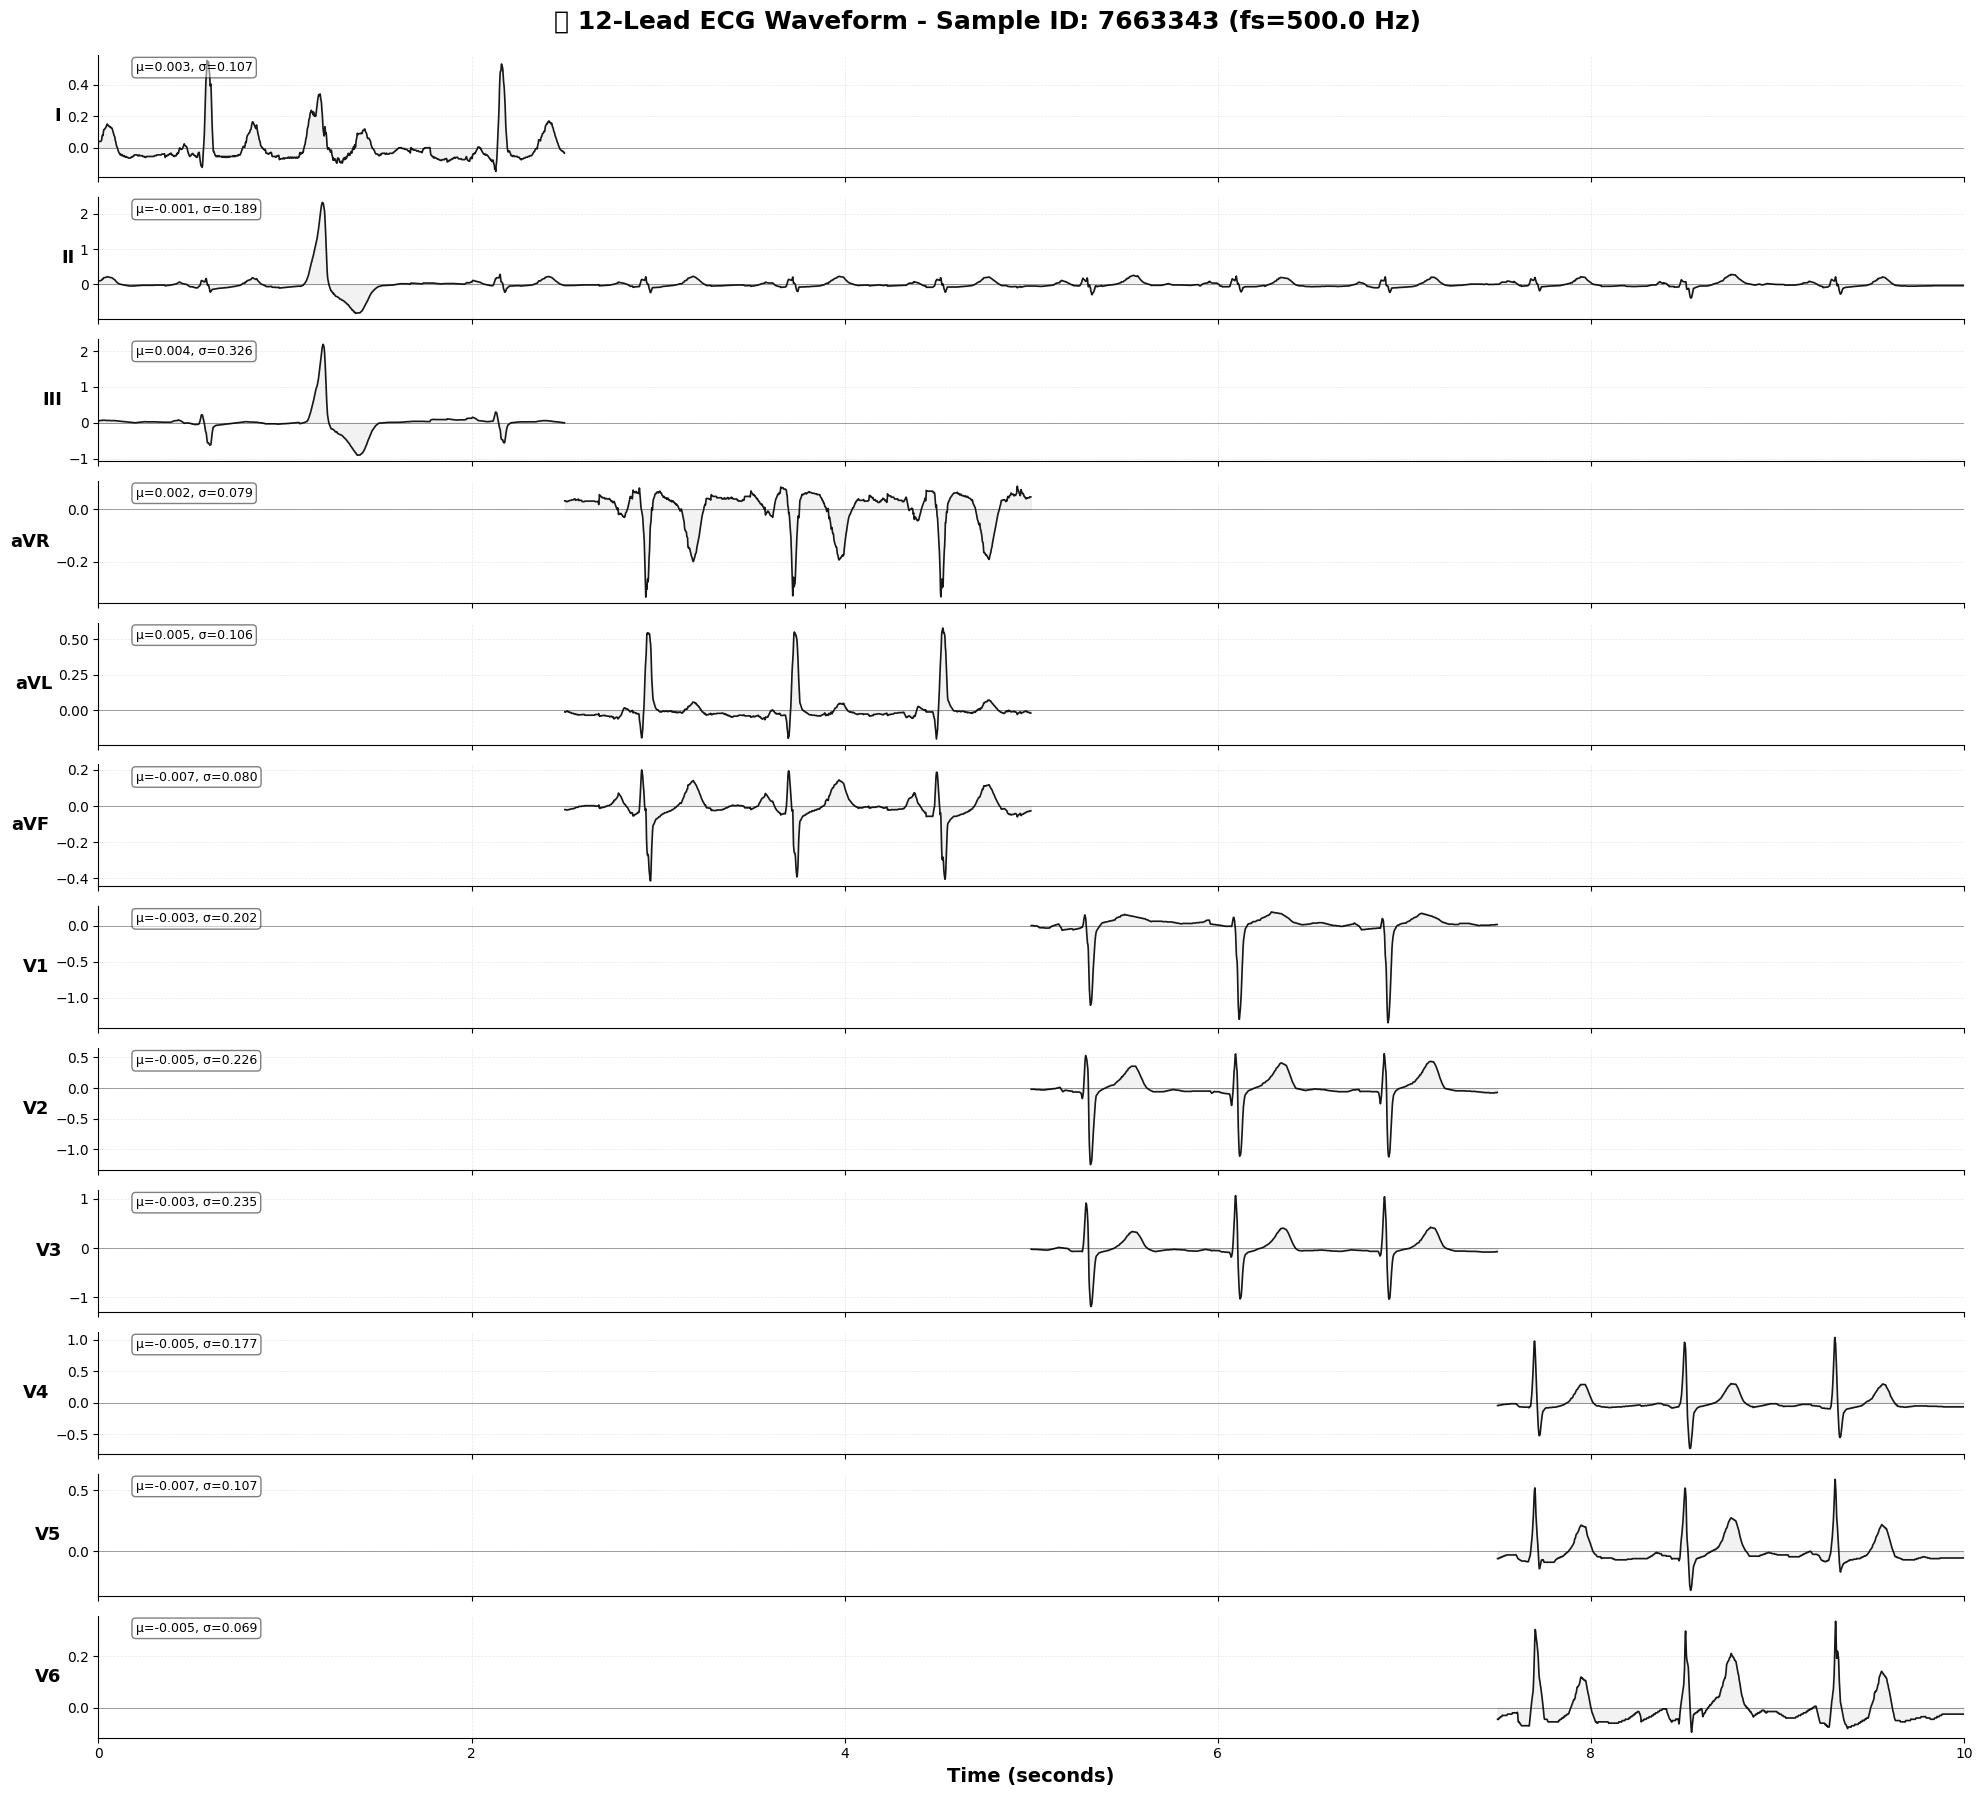

In [249]:
# 特徴量は平均のみなので調整する必要がありそう。
features = extract_ecg_features_by_id(ecg_id=sample_id, train_df=train_df, config=CONFIG, is_plot= True)

In [252]:
### 時系列的にnanになっているか？
# 自走がずれているのを調べる必要ありそう。

### image plot


#### DATALOADER